# Michael's dataset

https://data.wprdc.org/dataset/prt-of-allegheny-county-transit-stops

Measuring based on number of stops and routes per neighborhood, etc
Main important code is at the end (scoring stops)

In [18]:
# import dataset
import pandas as pd
stops = pd.read_csv('transitstops.csv')

Print out a list of all the different fields in the dataset:

In [19]:
print(stops.columns.tolist())

['_id', 'GEOIDFQ', 'OBJECTID', 'agency', 'change_log', 'comments', 'county', 'direction', 'empty_feat', 'end_date', 'feed_version', 'from_gtfs', 'hood', 'mode', 'muni', 'munihood_display', 'munihood_full', 'route_code', 'route_filter', 'route_sort', 'start_date', 'status_code', 'status_end_date', 'status_notes', 'status_start_date', 'stop_code', 'stop_id', 'stop_lat', 'stop_lon', 'stop_name', 'stop_route', 'svc_days', 'trips_7d', 'trips_sa', 'trips_su', 'trips_wd', 'geometry']


Print out a few of the fields that are more relevant to this project:

In [21]:
print(stops[['stop_name', 'hood', 'route_code']].head())

                               stop_name              hood          route_code
0                ARCH ST AT NORTH AVE FS  Allegheny Center                  54
1    ARCH ST OPP ALLEGHENY MIDDLE SCHOOL  Allegheny Center                  54
2  WEST COMMONS AT THE ALLEGHENY SR HOME  Allegheny Center               13,16
3        EAST COMMONS AT EAST OHIO ST NS  Allegheny Center  1,2,4,6,7,12,13,16
4              CEDAR AVE OPP FORELAND ST  Allegheny Center                  54


Print out the amount of bus and rail stops in each neighborhood:

In [32]:
stopsperhoodRail = stops[stops['mode'] == 'RAIL']['hood'].value_counts()
print(stopsperhoodRail.head())
print()
stopsperhoodBus = stops[stops['mode'] == 'BUS']['hood'].value_counts()
print(stopsperhoodBus.head())

hood
Beechview                    12
Central Business District     8
Mount Washington              4
Bon Air                       2
Beltzhoover                   2
Name: count, dtype: int64

hood
Bloomfield                  93
Mount Washington            91
Lincoln-Lemington-Belmar    80
Shadyside                   76
Squirrel Hill North         76
Name: count, dtype: int64


                         hood  stop_score
15  Central Business District       180.0
51           Mount Washington       118.7
8                  Bloomfield        98.5
66                  Shadyside        87.1
74        Squirrel Hill North        86.9
12                  Brookline        85.0
45   Lincoln-Lemington-Belmar        84.7
75        Squirrel Hill South        80.1
35                 Greenfield        79.2
27               East Liberty        72.3
                           hood  stop_score
57                      Oakwood         9.5
30                    Fairywood         9.0
3   Arlington-Arlington Heights         8.0
36                         Hays         7.0
19               Chartiers City         6.0
25                East Carnegie         4.0
53                New Homestead         4.0
80               Swisshelm Park         3.3
76                    St. Clair         3.0
65                    Ridgemont         2.0


<Axes: title={'center': 'Stop Score by Neighborhood'}, ylabel='hood'>

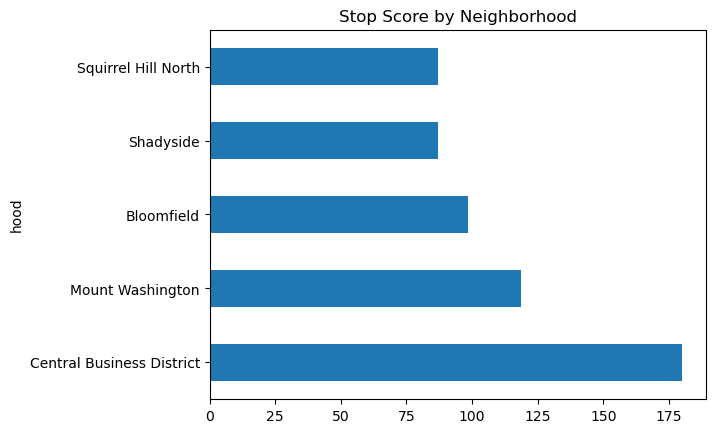

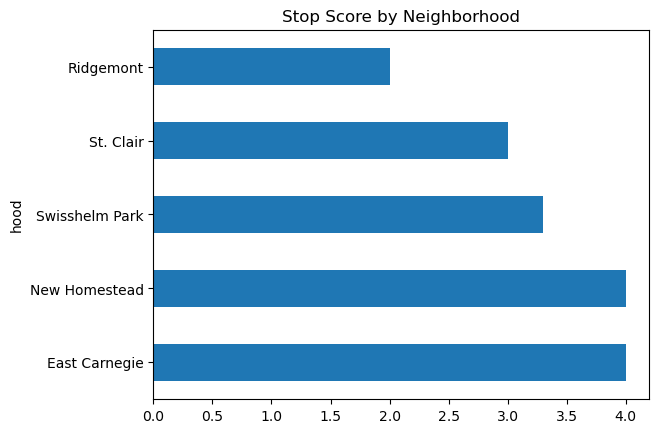

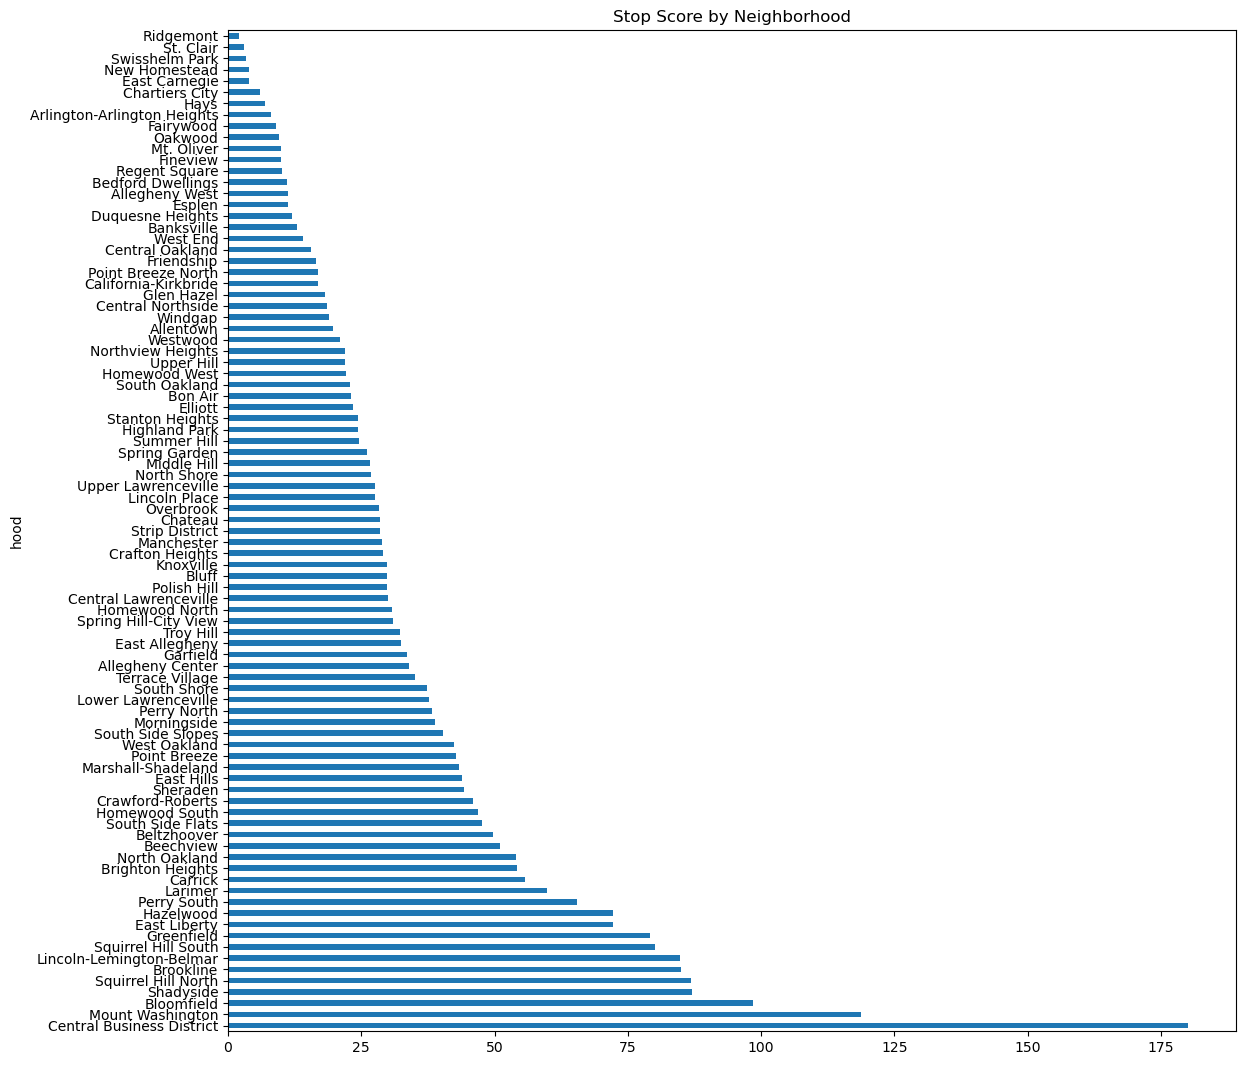

In [54]:
## main stop scoring

#count routes at each stop
stops['route_count'] = (
    stops['route_code'] #take route code cell
        .fillna('') #handle if cell empty (shouldn't be, but just in case)
        .str.count(',') + 1 #get number of routes (number of commas + 1)
)

#stop scoring
#bus stops get 1 + 0.1 for each additional bus route
#rail (T) stops get 3 + 3 for each additional T line (red/blue/silver)
stops['base'] = stops['mode'].map({'BUS': 1, 'RAIL': 3})
stops['additive'] = stops['mode'].map({'BUS': 0.1, 'RAIL': 3})

#final score - take base score, add additive score based on # of routes
stops['stop_score'] = (
    stops['base'] + 
    stops['additive'] * (stops['route_count'] - 1).clip(lower=0)
)

#combine by neighborhood
hood_scores = (
    stops.groupby('hood')['stop_score']
        .sum() #add up scores
        .reset_index() #fixes index (so it doesn't try treat hood as an int)
        .sort_values(by=['stop_score'], ascending=False) #sort by score
)

print(hood_scores.head(10))
print(hood_scores.tail(10))


#graph
hood_scores.head(5).plot(
    kind='barh', 
    x='hood', 
    y='stop_score',  
    title='Stop Score by Neighborhood',
    legend=False
)

hood_scores.tail(5).plot(
    kind='barh', 
    x='hood', 
    y='stop_score', 
    title='Stop Score by Neighborhood',
    legend=False
)

hood_scores.plot(
    kind='barh', 
    x='hood', 
    y='stop_score', 
    figsize=(13,13), 
    title='Stop Score by Neighborhood',
    legend=False
)